In [ ]:
"""
NOTEBOOK 3: DEEP LEARNING MODELS
==================================
Ethereum Mempool Attack Detection - Q1 Journal Submission
Models: MLP, 1D-CNN, LSTM, Attention-based Transformer
Author: Research Team
"""


In [1]:

# ============================================================================
# SECTION 1: IMPORTS AND SETUP
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time
import joblib
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, GlobalMaxPooling1D, Flatten,
    LSTM, Bidirectional, MultiHeadAttention, LayerNormalization,
    Input, GlobalAveragePooling1D, Add, Embedding, Lambda, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


In [2]:

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'serif'

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("DEEP LEARNING MODELS - TRAINING & EVALUATION")
print("=" * 80)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

CLASS_NAMES = {
    0: 'Normal/RBF',
    1: 'Double Spend',
    2: 'Race Attack',
    3: 'Volume Attack',
    4: 'Hybrid'
}


DEEP LEARNING MODELS - TRAINING & EVALUATION
TensorFlow version: 2.10.1
GPU Available: []


In [3]:

# ============================================================================
# SECTION 2: LOAD PREPROCESSED DATA
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 1: LOADING PREPROCESSED DATA")
print("=" * 80)

X_scaled = np.load('data/X_scaled.npy')
y = np.load('data/y.npy')

print(f"\n✓ Data loaded successfully")
print(f"  Feature matrix: {X_scaled.shape}")
print(f"  Target vector: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Prepare data for different architectures
X_train_2d = X_train  # For MLP (batch, features)
X_train_3d = X_train.reshape(-1, 12, 1)  # For CNN/LSTM (batch, timesteps, features)

X_test_2d = X_test
X_test_3d = X_test.reshape(-1, 12, 1)

# One-hot encode labels for some models
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"\n✓ Data shapes prepared:")
print(f"  2D (MLP): Train {X_train_2d.shape}, Test {X_test_2d.shape}")
print(f"  3D (CNN/LSTM): Train {X_train_3d.shape}, Test {X_test_3d.shape}")



SECTION 1: LOADING PREPROCESSED DATA

✓ Data loaded successfully
  Feature matrix: (103734, 12)
  Target vector: (103734,)

✓ Data shapes prepared:
  2D (MLP): Train (82987, 12), Test (20747, 12)
  3D (CNN/LSTM): Train (82987, 12, 1), Test (20747, 12, 1)


In [21]:

# ============================================================================
# SECTION 3: MODEL ARCHITECTURES
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 2: DEFINING MODEL ARCHITECTURES")
print("=" * 80)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)

# 1. DEEP MLP (Multi-Layer Perceptron)
def create_mlp():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(12,), kernel_initializer='he_normal'),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ], name='Deep_MLP')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. 1D-CNN (Convolutional Neural Network)
def create_1d_cnn():
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(12, 1), padding='same'),
        Dropout(0.2),
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        Dropout(0.2),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(5, activation='softmax')
    ], name='1D_CNN')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. LSTM (Long Short-Term Memory)
def create_lstm():
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(12, 1)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ], name='BiLSTM')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 4. Attention-based Transformer
def create_transformer():
    inputs = Input(shape=(12, 1))
    
    # 1. PROJECTION (1D -> 64D)
    x = Dense(64)(inputs) 
    
    # 2. POSITIONAL ENCODING (Fixed for Broadcasting)
    # Generate positions 0 to 11
    positions = tf.range(start=0, limit=12, delta=1)
    
    # Embed to (12, 64)
    pos_encoding = Embedding(input_dim=12, output_dim=64)(positions) 
    
    # CRITICAL FIX: Add a batch dimension of 1 at the start.
    # New shape becomes (1, 12, 64). 
    # This allows it to broadcast safely against (Batch_Size, 12, 64).
    pos_encoding = Lambda(lambda x: tf.expand_dims(x, axis=0))(pos_encoding)
    
    # Now adding them is safe
    x = Add()([x, pos_encoding]) 
    
    # 3. TRANSFORMER BLOCK
    # Attention
    attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    attn_output = Dropout(0.1)(attn_output)
    
    # Add & Norm 1
    x = Add()([x, attn_output])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Feed Forward Network
    ffn = Dense(64, activation="relu")(x)
    ffn = Dropout(0.1)(ffn)
    ffn = Dense(64)(ffn) 
    
    # Add & Norm 2
    x = Add()([x, ffn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # 4. CLASSIFICATION HEAD
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(5, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Transformer')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


models_dict = {
    'Deep MLP': (create_mlp, X_train_2d, X_test_2d),
    '1D-CNN': (create_1d_cnn, X_train_3d, X_test_3d),
    'BiLSTM': (create_lstm, X_train_3d, X_test_3d),
    'Transformer': (create_transformer, X_train_3d, X_test_3d)
}

print("✓ Models defined:")
for name in models_dict.keys():
    print(f"  • {name}")



SECTION 2: DEFINING MODEL ARCHITECTURES
✓ Models defined:
  • Deep MLP
  • 1D-CNN
  • BiLSTM
  • Transformer


In [22]:

# ============================================================================
# SECTION 4: MODEL TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 3: TRAINING DEEP LEARNING MODELS")
print("=" * 80)

trained_models = {}
training_histories = {}
training_times = {}

for model_name, (model_fn, X_tr, X_te) in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    model = model_fn()
    print(model.summary())
    
    # Training
    start_time = time()
    history = model.fit(
        X_tr, y_train_cat,
        validation_split=0.15,
        epochs=100,
        batch_size=128,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    training_time = time() - start_time
    
    trained_models[model_name] = model
    training_histories[model_name] = history
    training_times[model_name] = training_time
    
    # Evaluate
    y_pred_proba = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n  ✓ Training complete in {training_time:.2f}s")
    print(f"    Epochs trained: {len(history.history['loss'])}")
    print(f"    Final train loss: {history.history['loss'][-1]:.4f}")
    print(f"    Final val loss: {history.history['val_loss'][-1]:.4f}")
    print(f"    Test Accuracy: {acc:.4f}")
    print(f"    Test F1-Score: {f1:.4f}")
    
    # Save model
    safe_name = model_name.replace(' ', '_').replace('-', '_').lower()
    model.save(f'models/{safe_name}.h5')

print("\n✓ All models saved to 'models/' directory")



SECTION 3: TRAINING DEEP LEARNING MODELS

Training: Deep MLP
Model: "Deep_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 128)               1664      
                                                                 
 dropout_26 (Dropout)        (None, 128)               0         
                                                                 
 dense_29 (Dense)            (None, 64)                8256      
                                                                 
 dropout_27 (Dropout)        (None, 64)                0         
                                                                 
 dense_30 (Dense)            (None, 32)                2080      
                                                                 
 dropout_28 (Dropout)        (None, 32)                0         
                                                              


SECTION 4: TRAINING CURVES VISUALIZATION


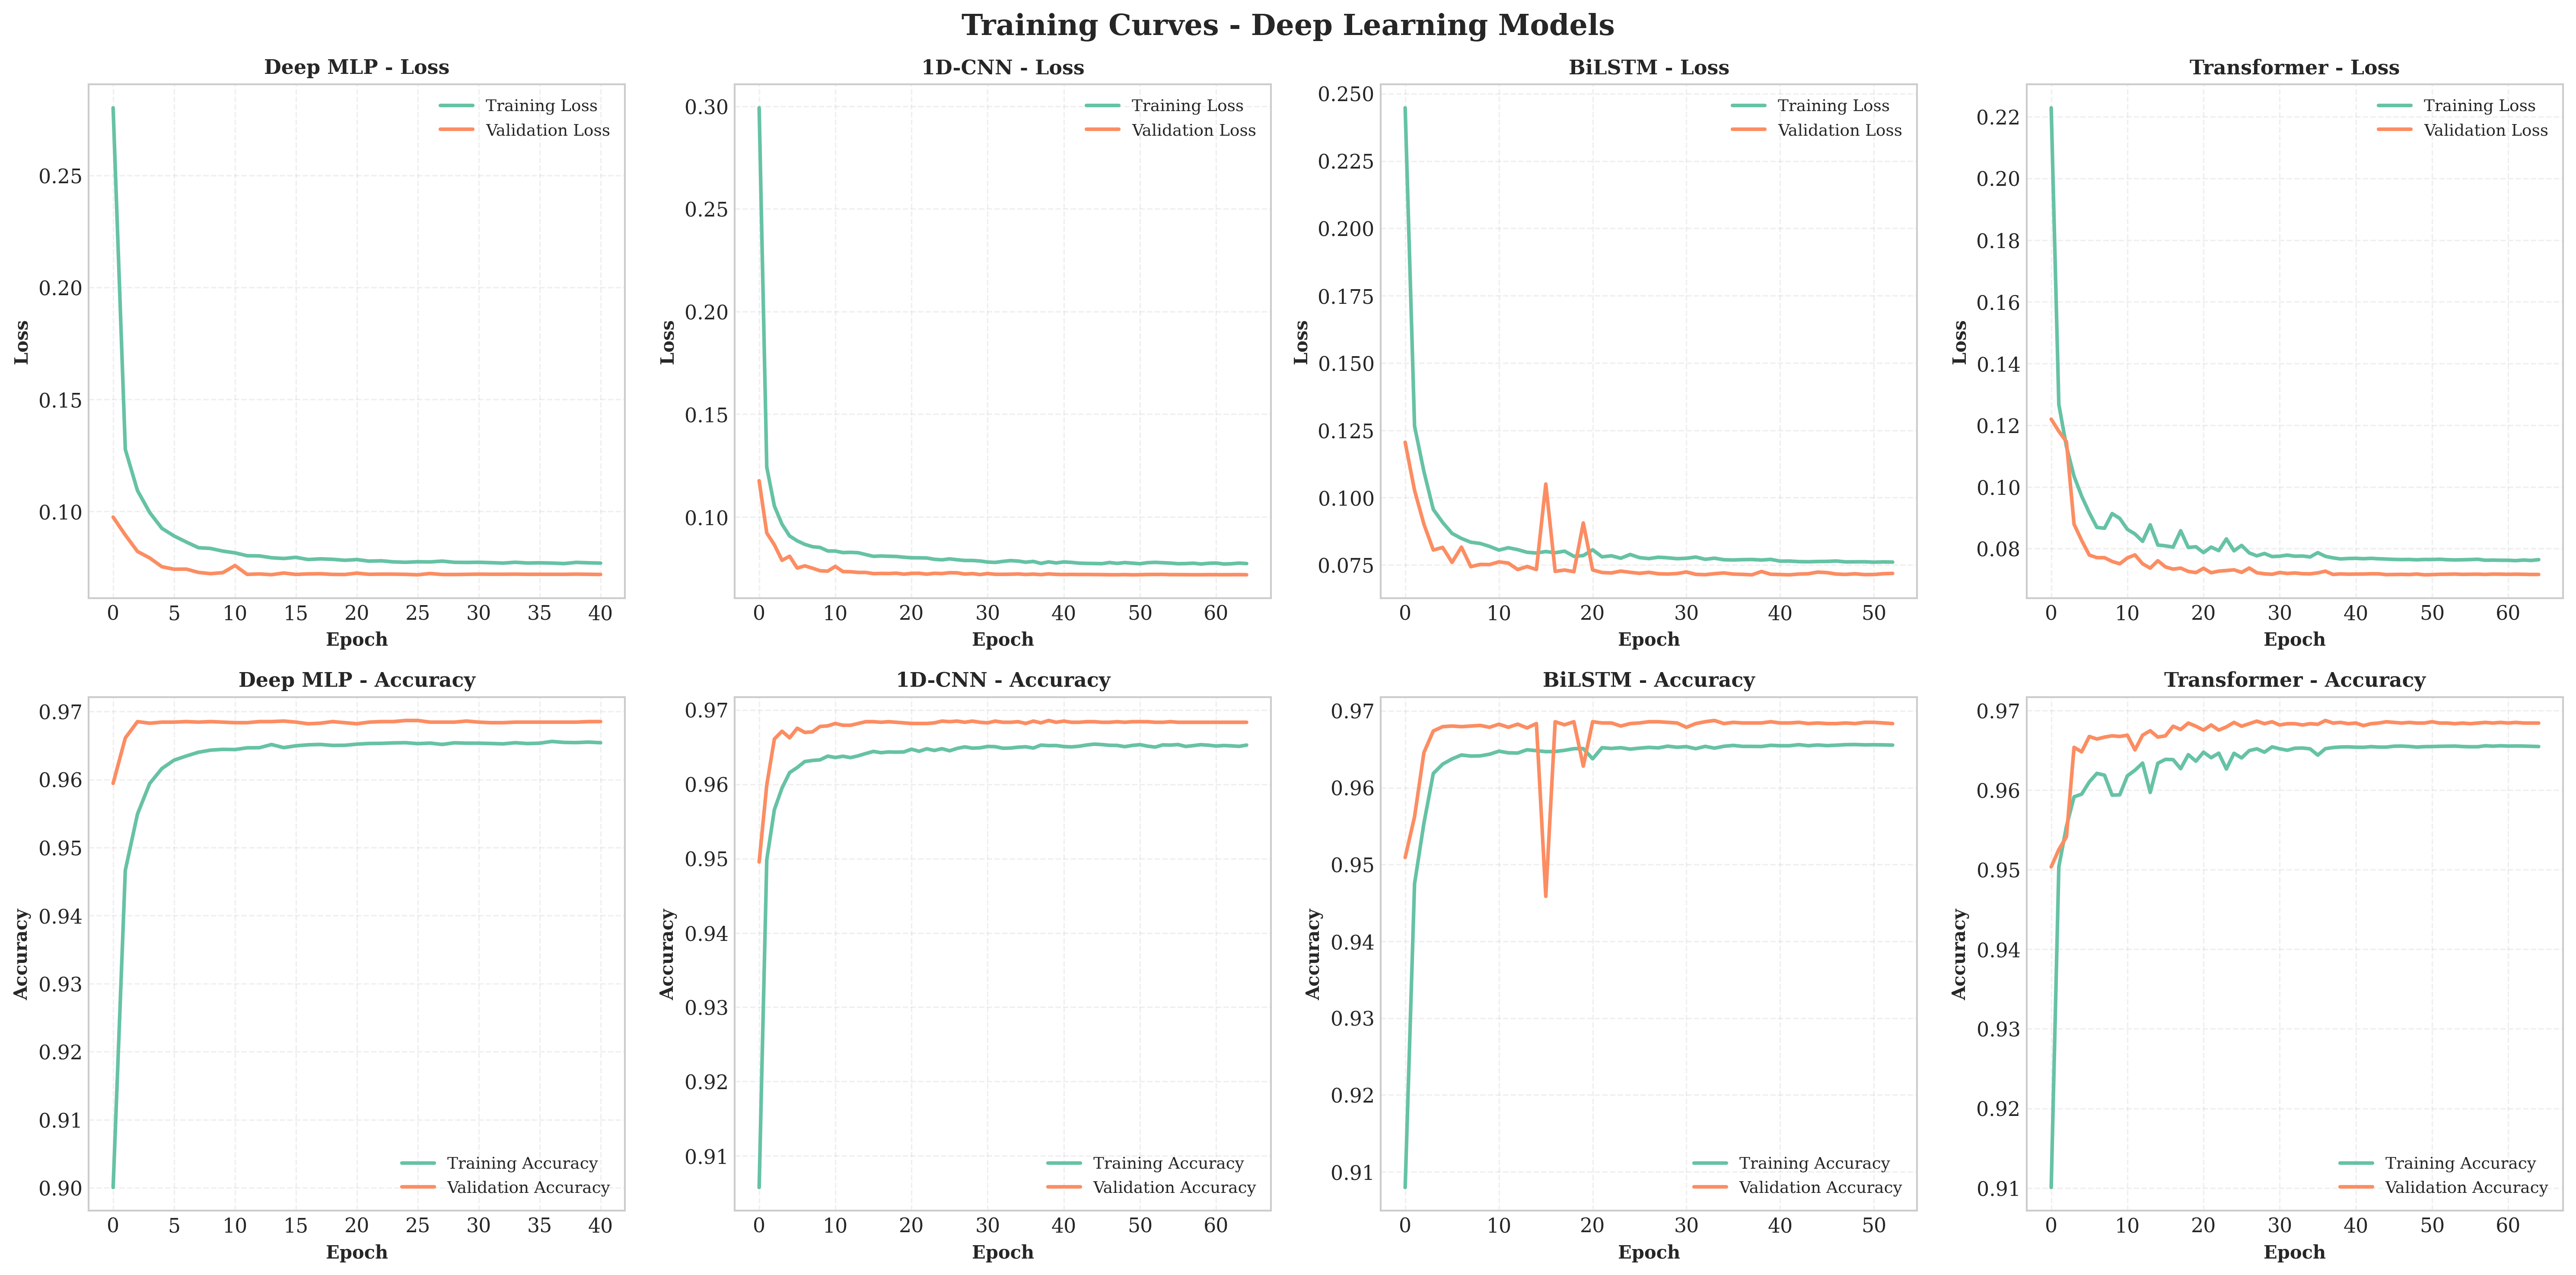


✓ Figure saved: results/15_dl_training_curves.png


In [23]:

# ============================================================================
# SECTION 5: TRAINING CURVES
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 4: TRAINING CURVES VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, (model_name, history) in enumerate(training_histories.items()):
    # Loss curve
    ax_loss = axes[0, idx]
    ax_loss.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax_loss.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax_loss.set_xlabel('Epoch', fontweight='bold', fontsize=10)
    ax_loss.set_ylabel('Loss', fontweight='bold', fontsize=10)
    ax_loss.set_title(f'{model_name} - Loss', fontweight='bold', fontsize=11)
    ax_loss.legend(fontsize=9)
    ax_loss.grid(alpha=0.3, linestyle='--')
    
    # Accuracy curve
    ax_acc = axes[1, idx]
    ax_acc.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax_acc.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax_acc.set_xlabel('Epoch', fontweight='bold', fontsize=10)
    ax_acc.set_ylabel('Accuracy', fontweight='bold', fontsize=10)
    ax_acc.set_title(f'{model_name} - Accuracy', fontweight='bold', fontsize=11)
    ax_acc.legend(fontsize=9)
    ax_acc.grid(alpha=0.3, linestyle='--')

plt.suptitle('Training Curves - Deep Learning Models', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('results/15_dl_training_curves.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n✓ Figure saved: results/15_dl_training_curves.png")


In [24]:

# ============================================================================
# SECTION 6: MODEL PREDICTIONS & EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 5: MODEL EVALUATION")
print("=" * 80)

predictions_dl = {}
prediction_probas_dl = {}
inference_times_dl = {}

for model_name, model in trained_models.items():
    _, X_te = models_dict[model_name][1:]
    
    # Measure inference time
    start_infer = time()
    y_pred_proba = model.predict(X_te, verbose=0)
    infer_time = (time() - start_infer) / len(X_te) * 1000  # ms per sample
    
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    predictions_dl[model_name] = y_pred
    prediction_probas_dl[model_name] = y_pred_proba
    inference_times_dl[model_name] = infer_time
    
    print(f"\n{model_name}:")
    print(f"  Inference time: {infer_time:.4f} ms/sample")
    print(classification_report(y_test, y_pred, 
                                target_names=[CLASS_NAMES[i] for i in range(5)],
                                digits=4))



SECTION 5: MODEL EVALUATION

Deep MLP:
  Inference time: 0.0335 ms/sample
               precision    recall  f1-score   support

   Normal/RBF     0.9569    0.9996    0.9778     15977
 Double Spend     1.0000    1.0000    1.0000       322
  Race Attack     0.9953    0.9907    0.9930       214
Volume Attack     0.9981    0.8156    0.8977      3905
       Hybrid     0.9939    0.9970    0.9954       329

     accuracy                         0.9649     20747
    macro avg     0.9888    0.9606    0.9728     20747
 weighted avg     0.9663    0.9649    0.9635     20747


1D-CNN:
  Inference time: 0.0479 ms/sample
               precision    recall  f1-score   support

   Normal/RBF     0.9566    0.9995    0.9776     15977
 Double Spend     1.0000    1.0000    1.0000       322
  Race Attack     0.9953    0.9907    0.9930       214
Volume Attack     0.9975    0.8149    0.8970      3905
       Hybrid     0.9970    0.9970    0.9970       329

     accuracy                         0.9646     20


SECTION 6: CONFUSION MATRICES


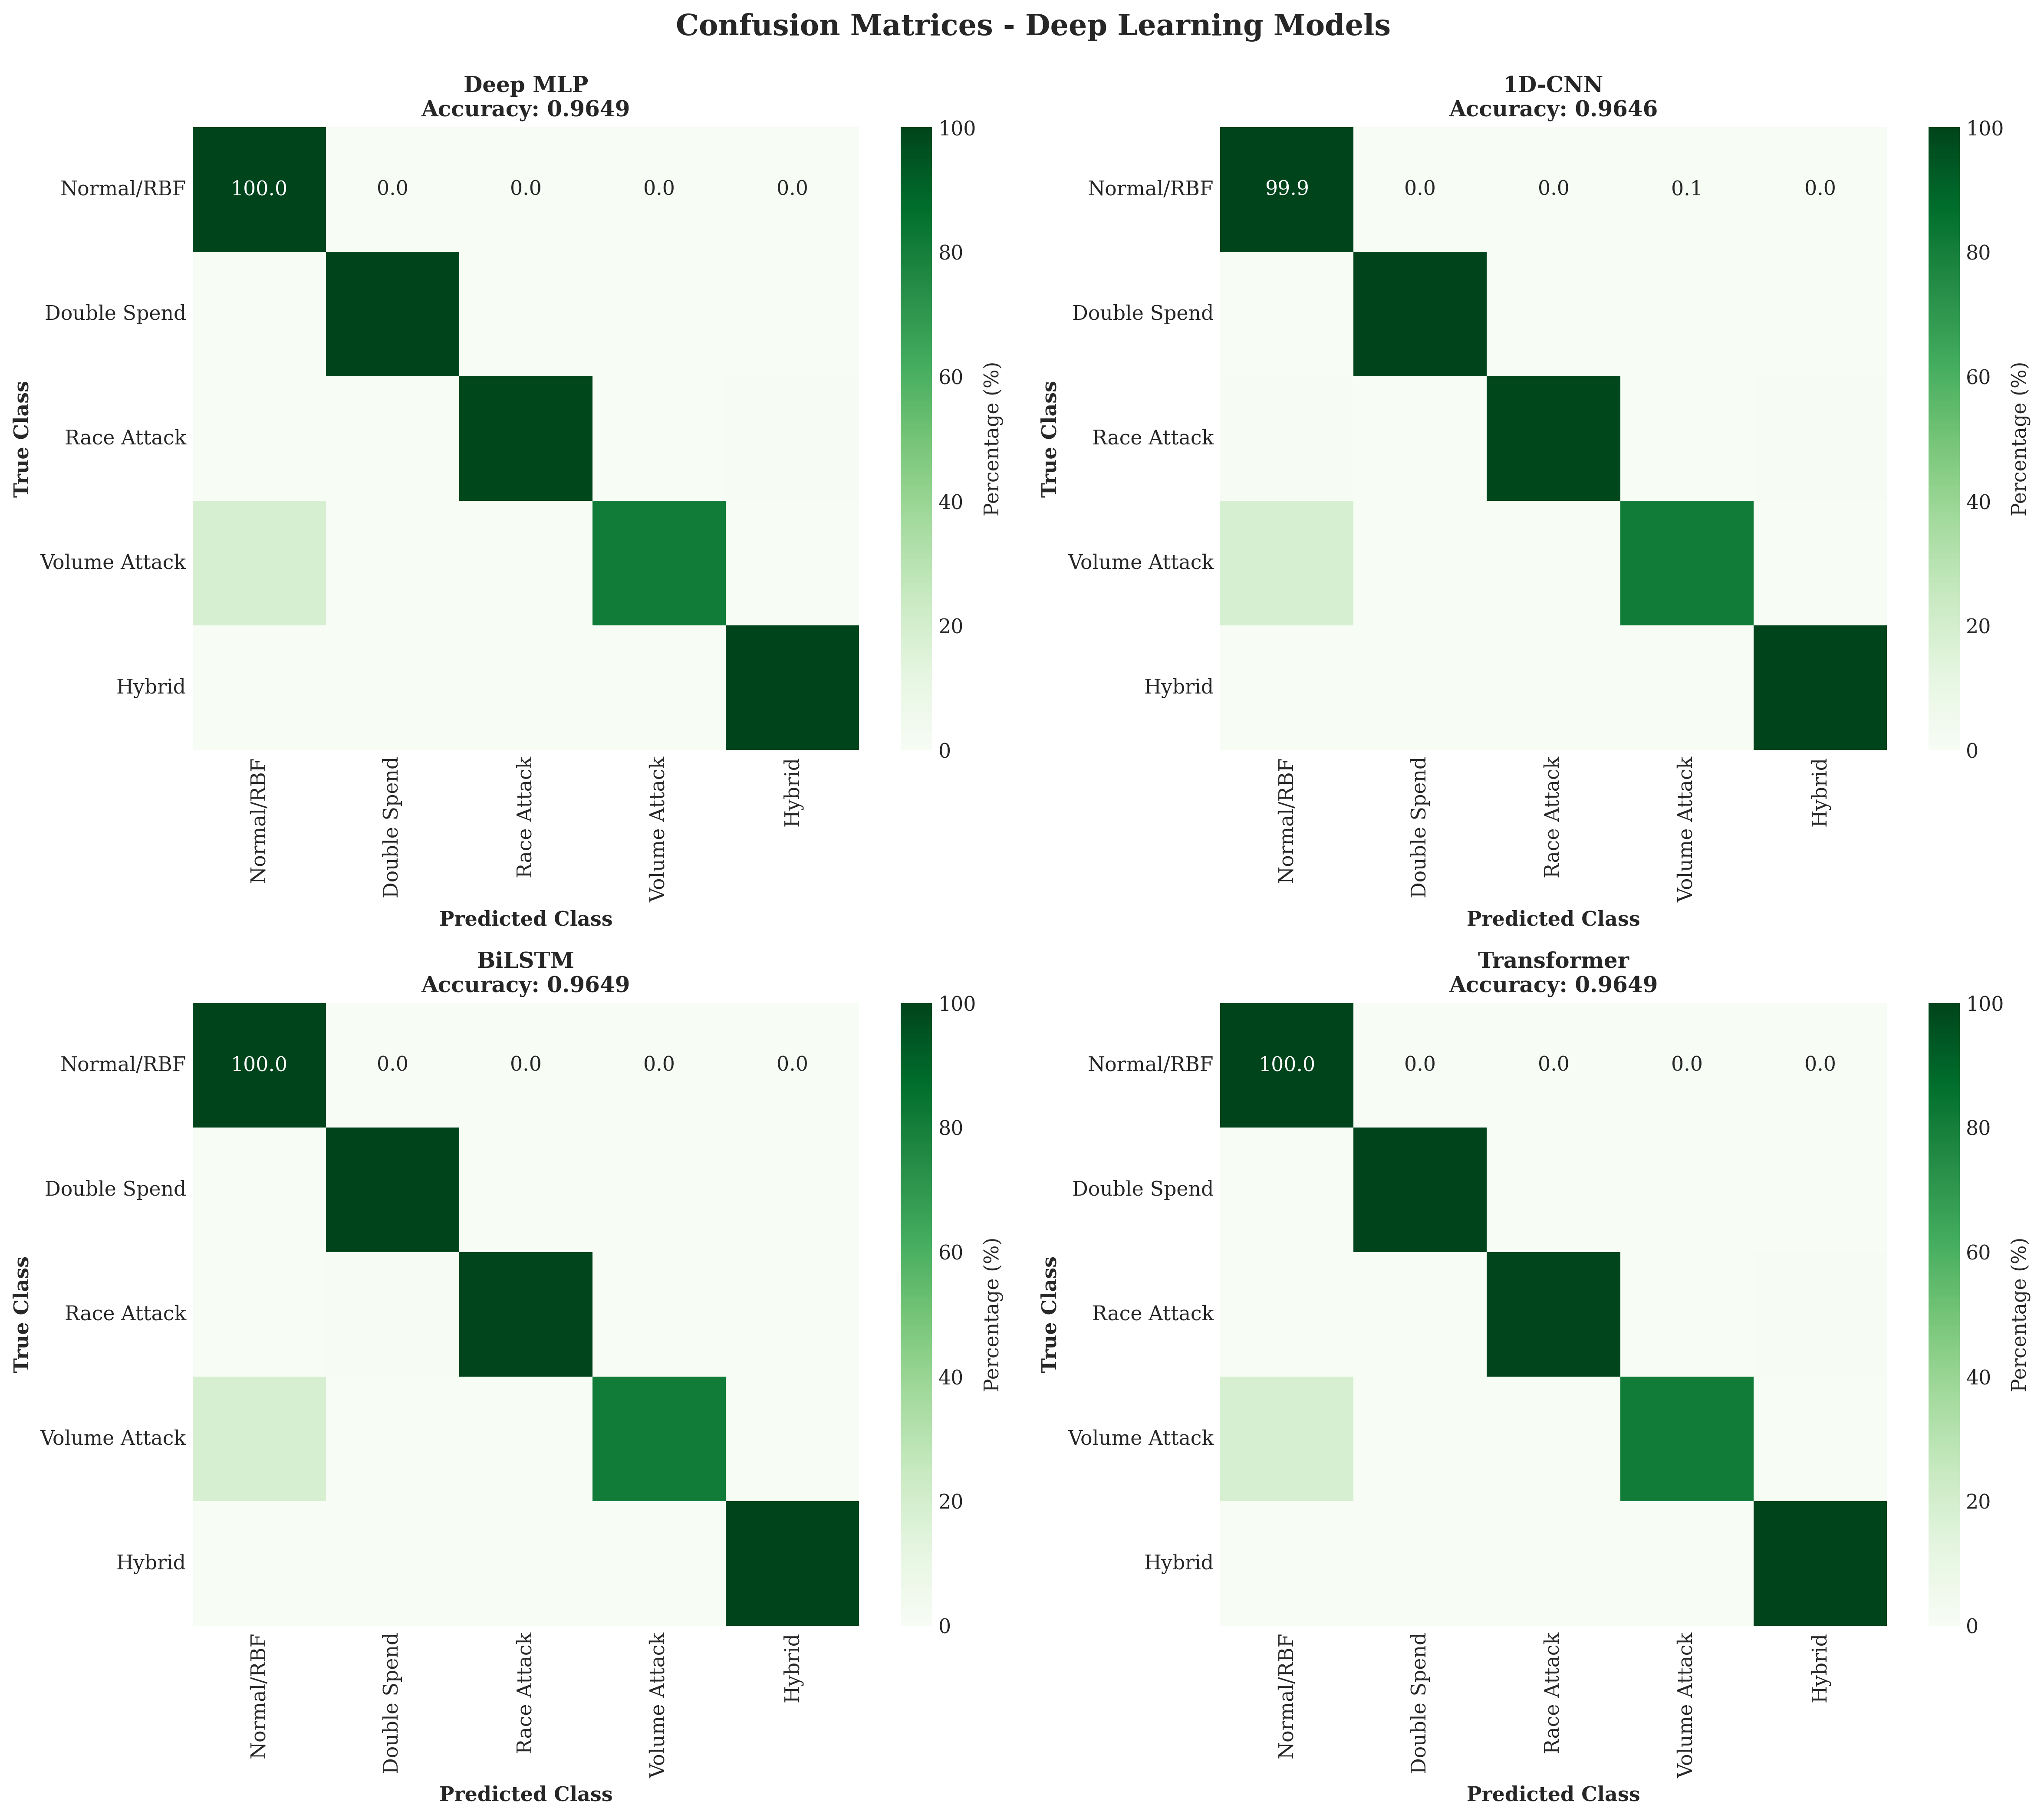


✓ Figure saved: results/16_confusion_matrices_dl.png


In [25]:

# ============================================================================
# SECTION 7: CONFUSION MATRICES
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 6: CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions_dl.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    ax = axes[idx]
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Greens', 
                xticklabels=[CLASS_NAMES[i] for i in range(5)],
                yticklabels=[CLASS_NAMES[i] for i in range(5)],
                ax=ax, cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)
    
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{model_name}\nAccuracy: {acc:.4f}', 
                fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Class', fontweight='bold', fontsize=11)
    ax.set_ylabel('True Class', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices - Deep Learning Models', 
             fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig('results/16_confusion_matrices_dl.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n✓ Figure saved: results/16_confusion_matrices_dl.png")



SECTION 7: ARCHITECTURE COMPARISON

      Model  Parameters  Accuracy  Precision   Recall  F1-Score  Training Time (s)  Inference Time (ms)
   Deep MLP       12165  0.964862   0.966282 0.964862  0.963484          52.019877             0.033506
     1D-CNN        8869  0.964621   0.966032 0.964621  0.963232         228.019181             0.047927
     BiLSTM       79493  0.964911   0.966331 0.964911  0.963532        1216.004287             0.175604
Transformer       79557  0.964862   0.966270 0.964862  0.963485        1179.343427             0.140464

✓ Comparison saved: results/17_dl_model_comparison.csv


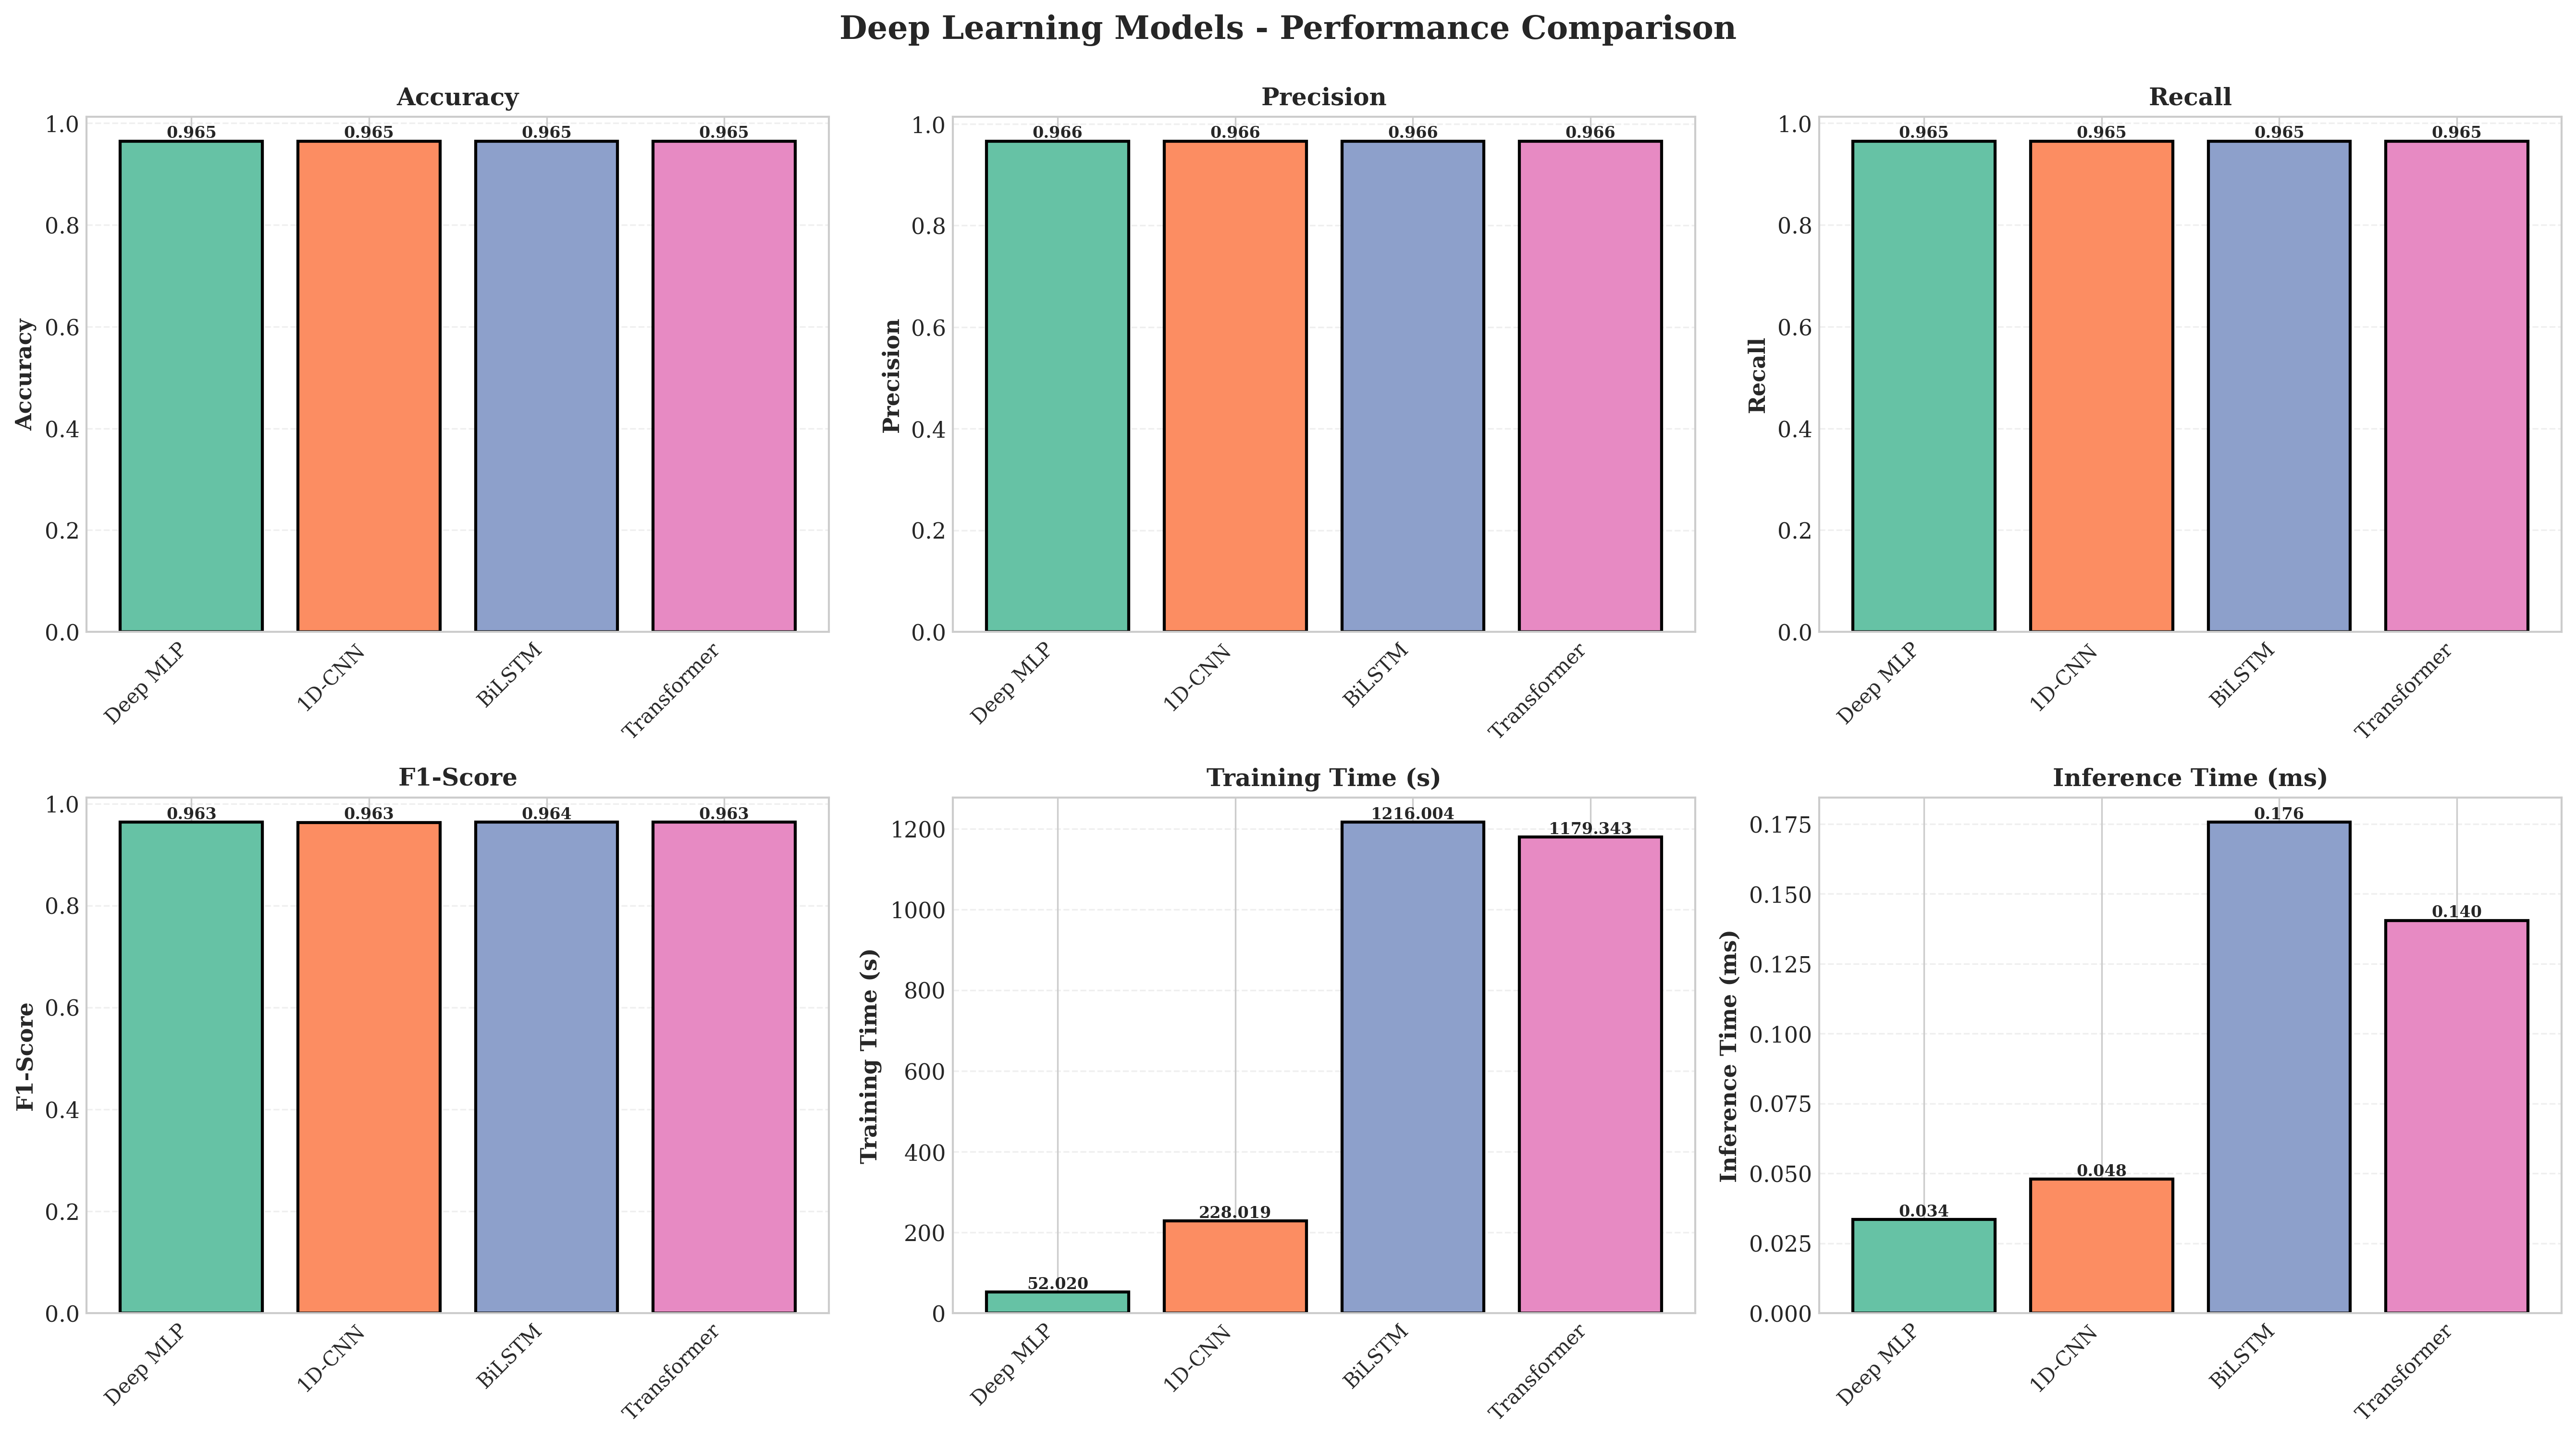


✓ Figure saved: results/18_dl_performance_comparison.png


In [26]:

# ============================================================================
# SECTION 8: ARCHITECTURE COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 7: ARCHITECTURE COMPARISON")
print("=" * 80)

comparison_data_dl = []
for model_name in trained_models.keys():
    y_pred = predictions_dl[model_name]
    model = trained_models[model_name]
    
    comparison_data_dl.append({
        'Model': model_name,
        'Parameters': model.count_params(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'Training Time (s)': training_times[model_name],
        'Inference Time (ms)': inference_times_dl[model_name]
    })

comparison_df_dl = pd.DataFrame(comparison_data_dl)
print("\n" + comparison_df_dl.to_string(index=False))

comparison_df_dl.to_csv('results/17_dl_model_comparison.csv', index=False)
print("\n✓ Comparison saved: results/17_dl_model_comparison.csv")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Inference Time (ms)']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    bars = ax.bar(range(len(comparison_df_dl)), comparison_df_dl[metric], 
                   color=sns.color_palette("Set2", len(comparison_df_dl)),
                   edgecolor='black', linewidth=1.5)
    ax.set_xticks(range(len(comparison_df_dl)))
    ax.set_xticklabels(comparison_df_dl['Model'], rotation=45, ha='right', fontsize=10)
    ax.set_ylabel(metric, fontweight='bold', fontsize=11)
    ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}' if metric not in ['Parameters'] else f'{int(height):,}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Deep Learning Models - Performance Comparison', 
             fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig('results/18_dl_performance_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n✓ Figure saved: results/18_dl_performance_comparison.png")


In [27]:

# ============================================================================
# SECTION 9: ABLATION STUDY (CNN WITH/WITHOUT CONV LAYERS)
# ============================================================================
print("\n" + "=" * 80)
print("SECTION 8: ABLATION STUDY (CNN Architecture)")
print("=" * 80)

# CNN without convolution (just dense layers on flattened input)
def create_cnn_ablation():
    model = Sequential([
        Flatten(input_shape=(12, 1)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ], name='CNN_Ablation_No_Conv')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Training CNN without convolutional layers...")
cnn_ablation = create_cnn_ablation()
history_ablation = cnn_ablation.fit(
    X_train_3d, y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

y_pred_ablation = np.argmax(cnn_ablation.predict(X_test_3d, verbose=0), axis=1)
acc_ablation = accuracy_score(y_test, y_pred_ablation)
acc_full_cnn = accuracy_score(y_test, predictions_dl['1D-CNN'])

print(f"\n✓ Ablation Study Results:")
print(f"  CNN with Conv layers:    {acc_full_cnn:.4f}")
print(f"  CNN without Conv layers: {acc_ablation:.4f}")
print(f"  Performance drop:        {(acc_full_cnn - acc_ablation):.4f} ({(acc_full_cnn - acc_ablation)/acc_full_cnn*100:.2f}%)")



SECTION 8: ABLATION STUDY (CNN Architecture)
Training CNN without convolutional layers...

✓ Ablation Study Results:
  CNN with Conv layers:    0.9646
  CNN without Conv layers: 0.9648
  Performance drop:        -0.0001 (-0.01%)


In [28]:

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("DEEP LEARNING TRAINING COMPLETE")
print("=" * 80)

print("\n🏆 Best Deep Learning Model (by F1-Score):")
best_dl = comparison_df_dl.loc[comparison_df_dl['F1-Score'].idxmax()]
print(f"  Model: {best_dl['Model']}")
print(f"  F1-Score: {best_dl['F1-Score']:.4f}")
print(f"  Accuracy: {best_dl['Accuracy']:.4f}")
print(f"  Parameters: {int(best_dl['Parameters']):,}")
print(f"  Inference Time: {best_dl['Inference Time (ms)']:.4f} ms/sample")

print("\n✅ Generated Artifacts:")
artifacts_dl = [
    '15_dl_training_curves.png',
    '16_confusion_matrices_dl.png',
    '17_dl_model_comparison.csv',
    '18_dl_performance_comparison.png'
]
for i, artifact in enumerate(artifacts_dl, 1):
    print(f"  {i}. results/{artifact}")

print("\n🎯 Ready for Final Comparison & Explainability (Notebook 4)")
print("=" * 80)


DEEP LEARNING TRAINING COMPLETE

🏆 Best Deep Learning Model (by F1-Score):
  Model: BiLSTM
  F1-Score: 0.9635
  Accuracy: 0.9649
  Parameters: 79,493
  Inference Time: 0.1756 ms/sample

✅ Generated Artifacts:
  1. results/15_dl_training_curves.png
  2. results/16_confusion_matrices_dl.png
  3. results/17_dl_model_comparison.csv
  4. results/18_dl_performance_comparison.png

🎯 Ready for Final Comparison & Explainability (Notebook 4)


In [5]:
# In Notebook 3, add a new cell at the end:
print("\n🔧 Re-training Transformer with proper saving...")

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)

def create_transformer():
    inputs = Input(shape=(12, 1))
    
    # 1. PROJECTION (1D -> 64D)
    x = Dense(64)(inputs) 
    
    # 2. POSITIONAL ENCODING (Fixed for Broadcasting)
    # Generate positions 0 to 11
    positions = tf.range(start=0, limit=12, delta=1)
    
    # Embed to (12, 64)
    pos_encoding = Embedding(input_dim=12, output_dim=64)(positions) 
    
    # CRITICAL FIX: Add a batch dimension of 1 at the start.
    # New shape becomes (1, 12, 64). 
    # This allows it to broadcast safely against (Batch_Size, 12, 64).
    pos_encoding = Lambda(lambda x: tf.expand_dims(x, axis=0))(pos_encoding)
    
    # Now adding them is safe
    x = Add()([x, pos_encoding]) 
    
    # 3. TRANSFORMER BLOCK
    # Attention
    attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    attn_output = Dropout(0.1)(attn_output)
    
    # Add & Norm 1
    x = Add()([x, attn_output])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Feed Forward Network
    ffn = Dense(64, activation="relu")(x)
    ffn = Dropout(0.1)(ffn)
    ffn = Dense(64)(ffn) 
    
    # Add & Norm 2
    x = Add()([x, ffn])
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # 4. CLASSIFICATION HEAD
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(5, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Transformer')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

transformer = create_transformer()
history = transformer.fit(
    X_train_3d, y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
y_pred = np.argmax(transformer.predict(X_test_3d, verbose=0), axis=1)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Save as SavedModel
transformer.save('models/transformer', save_format='tf')
print("✓ Transformer saved correctly as SavedModel")


🔧 Re-training Transformer with proper saving...
Epoch 1/100
552/552 [==============================] - 16s 26ms/step - loss: 0.2477 - accuracy: 0.8986 - val_loss: 0.1324 - val_accuracy: 0.9514 - lr: 0.0010
Epoch 2/100
552/552 [==============================] - 15s 26ms/step - loss: 0.1229 - accuracy: 0.9518 - val_loss: 0.1178 - val_accuracy: 0.9535 - lr: 0.0010
Epoch 3/100
552/552 [==============================] - 14s 26ms/step - loss: 0.1081 - accuracy: 0.9567 - val_loss: 0.0983 - val_accuracy: 0.9642 - lr: 0.0010
Epoch 4/100
552/552 [==============================] - 14s 26ms/step - loss: 0.0987 - accuracy: 0.9595 - val_loss: 0.0803 - val_accuracy: 0.9661 - lr: 0.0010
Epoch 5/100
552/552 [==============================] - 14s 25ms/step - loss: 0.0950 - accuracy: 0.9597 - val_loss: 0.0828 - val_accuracy: 0.9646 - lr: 0.0010
Epoch 6/100
552/552 [==============================] - 15s 27ms/step - loss: 0.0920 - accuracy: 0.9605 - val_loss: 0.0768 - val_accuracy: 0.9664 - lr: 0.0010
Epo

INFO:tensorflow:Assets written to: models/transformer\assets


INFO:tensorflow:Assets written to: models/transformer\assets


✓ Transformer saved correctly as SavedModel
